# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [2]:
STUDENT_NAME = "Trần Trung Quân"  # TODO: Họ và tên
STUDENT_ID = "2550204"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Trung Quân (2550204)


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/macbookair/Desktop/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [4]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [24]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)


In [25]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [7]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [26]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [27]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [10]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [ ]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.argwhere(review_mask).flatten()

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [12]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [30]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho 1 mẫu xe gồm các đặc điểm của nó như động cơ, kích thước... và giá bán của nó.
2. Ký hiệu missing value trong CSV là dấu ?.
3. Symboling là số đại diện cho mức độ rủi ro bảo hiểm của xe, symboling càng cao thì xe càng rủi ro.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [48]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [49]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [50]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isnull().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
- Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột biểu diễn một kiểu dữ liệu và đơn vị khác nhau. Điền chung một số sẽ khiến thông kê sai lệch, không thực tế.
- Nên lựa chọn drop vào bài EDA này cho price vì price là mục tiêu mình cần xác định. Nếu fill sẽ làm sai lệch những phân tích sau đó.
- Normalized_losses thiếu nhiều dữ liệu hơn các cột khác làm cho dữ liệu bị thu hẹp, dẫn đến những tính toán, phân tích không còn độ chính xác cao.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [51]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [52]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [53]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index] 
price_outlier_mask = (price_z > 2) | (price_z < -2)
price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [54]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_price_corr = np.corrcoef(analysis_df['engine_size'], analysis_df['price'])[0, 1]
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

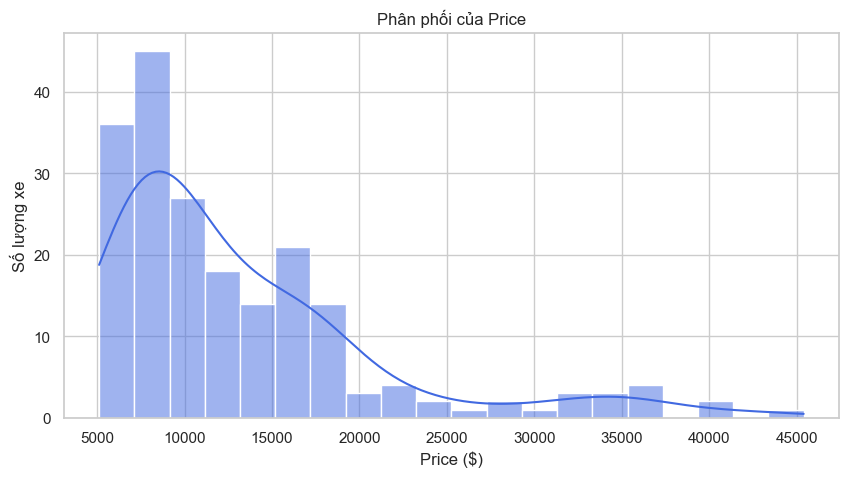

In [42]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], kde=True, bins=20, color='royalblue')
plt.title('Phân phối của Price')
plt.xlabel('Price ($)')
plt.ylabel('Số lượng xe')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Phân phối lệch phải, phần lớn xe có mức giá thấp và trung bình (từ 5000$ đến 20000$) và đỉnh điểm số lượng xe cao nhất trong mức giá khoảng 7000$ đến 8000$. Còn từ mức giá từ 20000$ trở lên thì số lượng xe rất ít.

## M2.2 Dataset có cân bằng theo body style không?

/var/folders/bj/0bwd3m1x70l0p9d8hdcfk6sr0000gn/T/ipykernel_90556/542880501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=order, palette='viridis')


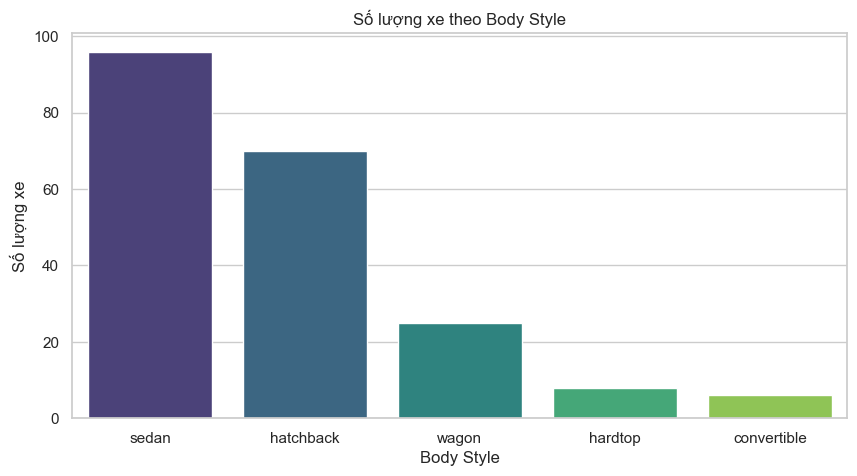

In [43]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10, 5))
order = df_clean['body_style'].value_counts().index
sns.countplot(data=df_clean, x='body_style', order=order, palette='viridis')
plt.title('Số lượng xe theo Body Style')
plt.xlabel('Body Style')
plt.ylabel('Số lượng xe')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
Số lượng xe theo Body Style phân bố không đồng đều, tập trung chủ yếu là sedan, hatchback và giảm dần theo thứ tự là wagon, hardtop, convertible. Đặc biệt hardtop và convertible có sự chênh lệch rất lớn so với sedan và hatchback, chiếm số lượng xe rất ít, chỉ khoảng 5 chiếc.

## M2.3 Price khác nhau theo body style ra sao?

/var/folders/bj/0bwd3m1x70l0p9d8hdcfk6sr0000gn/T/ipykernel_90556/1241986409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


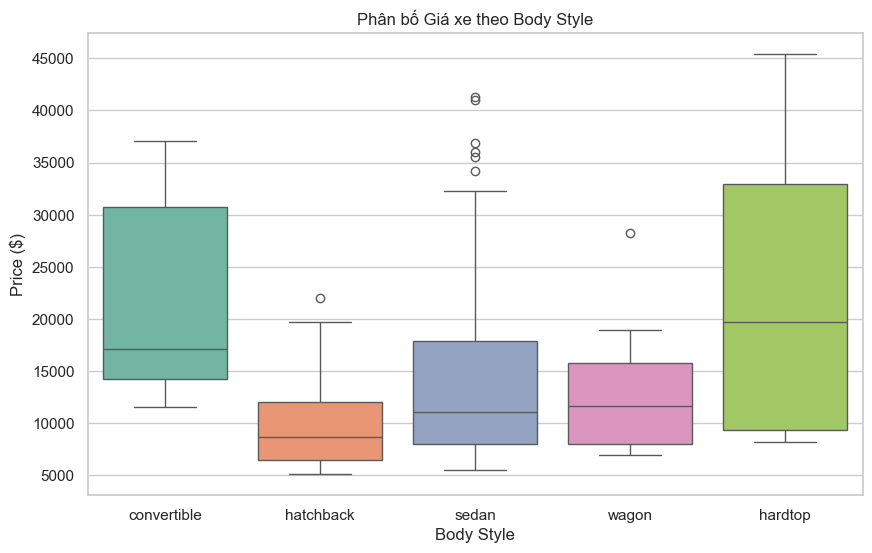

In [44]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')
plt.title('Phân bố Giá xe theo Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Dòng xe convertible và hardtop có mức giá trung bình, trong đó hard top có độ biến thiên giá lớn nhất (từ khoảng 10000$ đến 33000$). Còn hatchback, sedan, wagon có giá cả khá thấp, chỉ dao động trong khoảng 6000$ đến 18000$ và có độ biến thiên giá không quá lớn. Nhưng đặc biệt nhất là sedan khi có nhiều điểm outliers chứng tỏ vẫn có một số loại xe đặc biệt mang mức giá vượt trội so với tầm trung.

## M2.4 Engine size liên quan thế nào tới price?

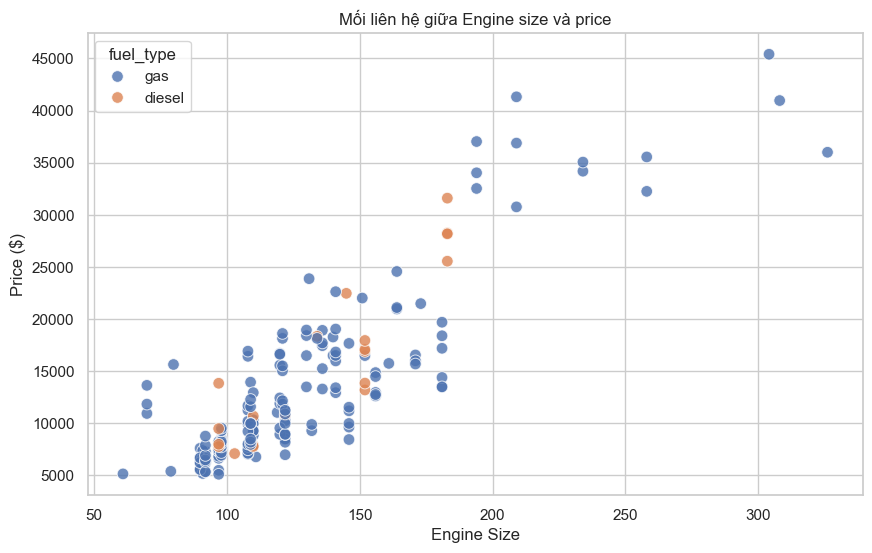

In [45]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', s=70, alpha=0.8)
plt.title('Mối liên hệ giữa Engine size và price')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Engine Size và Price có tương quan tuyến tính thuận, đa số khi engine size càng lớn thì giá sẽ càng cao. Xe chạy bằng xăng có sự phân bố rộng cả về price và engine size còn xe chạy bằng diesel tập trung ở khu vực giữa và phía bên trái hơn.

## M2.5 Các feature numeric tương quan ra sao?

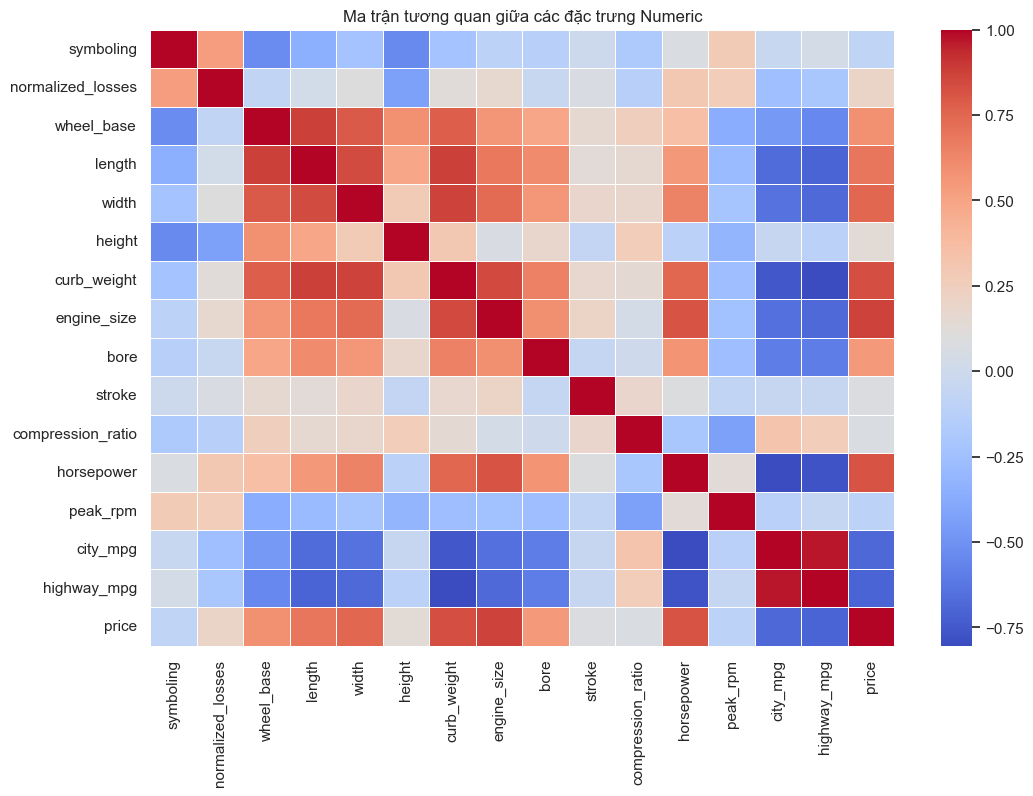

In [46]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng Numeric')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Các đặc trưng như wheel_base, length, width, height, curb_height, engine_size, bore gần như đều có tương quan thuận với nhau, các đặc trưng đó tập trung tạo thành 1 vùng gam màu nóng khá rõ rệt. Trong khi đó, cũng chính các đặc trưng đó lại tương quan nghịch với symboling, peak_rpm, city_mpg, highway_mpg.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

/var/folders/bj/0bwd3m1x70l0p9d8hdcfk6sr0000gn/T/ipykernel_90556/1473041584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='fuel_type', y='city_mpg', palette='Set1', errorbar='sd')


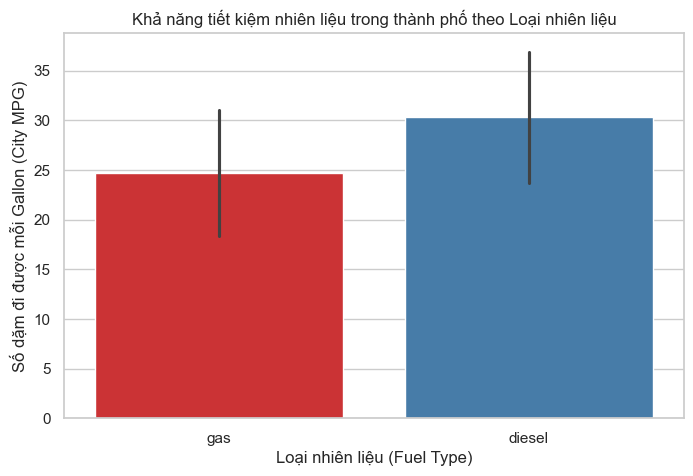

In [47]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='fuel_type', y='city_mpg', palette='Set1', errorbar='sd')
plt.title('Khả năng tiết kiệm nhiên liệu trong thành phố theo Loại nhiên liệu')
plt.xlabel('Loại nhiên liệu (Fuel Type)')
plt.ylabel('Số dặm đi được mỗi Gallon (City MPG)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Số dặm đi được trên mỗi Gallon gas và diesel chênh nhau không quá nhiều (gas: 25 dặm/gallon, diesel: 30 dặm/gallon) nên khả năng tiết kiệm nhiên liệu của 2 loại nhiên liệu này khá tương đương nhau.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
- Có sự tương quan tuyến tính thuận giữa price và engine size, dẫn chứng: các chấm dữ liệu có xu hướng đi lên tuyến tính ở biểu đồ scatterplot. Bên cạnh đó, số lượng các xe ở mức giá thấp khá được ưa chuộng, dẫn chứng: biểu đồ KDE của price và số lượng xe lệch phải, tập trung số lượng chủ yếu khi giá xe dưới 20000$. Ngoài ra, xe càng đắt tiền và động cơ càng lớn thì càng hao nhiên liệu, dẫn chứng: tương quan nghịch màu xanh giữa price và engine size so với city_mpg và highway_mpg trên bản đồ heatmap.
- Hạn chế của dataset: số lượng mẫu xe không quá nhiều, trong khi đó vẫn còn nhiều số lượng bị khuyết; có sự chênh lệch lớn giữa một số dữ liệu như xe chạy bằng gas chiếm phần lớn so với xe chạy bằng diesel... làm cho độ tin cậy của dữ liệu bị giảm.
- Ví dụ correlation nhưng không causation: price và horsepower có tương quan thuận khá cao nhưng thực chất điều dẫn đến horsepower cao chính là nhờ vào động cơ của xe như engine size, curb_weight... làm cho xe trở nên mạnh hơn.
- Câu hỏi có thể phân tích tiếp đó chính là hãng xe, có thể 2 xe sẽ khá tương đồng về các thông số kĩ thuật nhưng thương hiệu, cơ sở sản xuất có thể làm giá của chiếc xe thay đổi nhiều.